In [ ]:
#!/usr/bin/env python
# coding: utf-8

In[ ]:


<br>
1.PyMuPDF is a high-performance Python library for data extraction, analysis, <br>
conversion & manipulation of PDF (and other) documents. PyMuPDF is hosted on GitHub and registered on PyPI.<br>
2.Pytesseract or Python-tesseract is an OCR tool for python that also serves as a wrapper <br>
for the Tesseract-OCR Engine.<br>


# Extracting flowcharts from the patent pdfs

In[ ]:

In [3]:
import fitz  #import PyMuPDF module
import os #module used to interact with local Operating System.

# locating the folder with the patent pdfs
files = os.listdir('/Users/abdulkareemarbaz/Documents/Responsible AI Lab/patent pdfs') 
folder_path = '/Users/abdulkareemarbaz/Documents/Responsible AI Lab/patent pdfs' # recording the path to folder

# for each file in folder get flowcharts from the pdfs
for file_name in files: 
    file_path = os.path.join(folder_path, file_name)
    pdf_document = fitz.open(file_path)
    
    # iterate through each page in pdf file
    for page_number in range(len(pdf_document)): 
        page = pdf_document.load_page(page_number)
        image_list = page.get_images(full=True)

        # iterate through the pages and extract images from them.
        for img_index, img in enumerate(image_list):
            xref = img[0]
            base_image = pdf_document.extract_image(xref) # extracting images 
            image_data = base_image["image"]

            with open(f'/Users/abdulkareemarbaz/Documents/Responsible AI Lab/images1/page_{page_number}_img_{img_index}.jpg', 'wb') as f:
                
                # saving each image in the particular folder
                f.write(image_data) 

pdf_document.close() # Close the PDF file

In[60]:

In [ ]:
print(sorted(files))

# Extracting images from the folder

In[18]:

In [3]:
import os
from PIL import Image
import cv2

# extract the images from patent pdfs stored in this folder
files = os.listdir('Patent Images') 
folder_path = 'Patent Images'

# tore the images in the list
image_list = []
for file_name in sorted(files):
    file_path = os.path.join(folder_path, file_name)
    if os.path.isfile(file_path) and file_name.lower().endswith(('.png','.jpg')):
        
        #extracting images from the folder using imread from cv2
        image = cv2.imread(file_path)
        
        #dont images which are not None
        if type(image) is not(None):
            image_list.append(image)

# Pre processing obtained images

In[20]:

In [5]:
import cv2
image = cv2.imread("/Users/abdulkareemarbaz/Documents/Responsible AI Lab")

In[19]:

In [13]:
import cv2
import numpy as np
from numpy import asarray
gray_images = []
binary_images = []

# pre processing the images to obtain a better image quality.
def preprocess(image):
    
    #converting image to grayscale image
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    #converting images to binary images i.e white and black 
    _, binary_image = cv2.threshold(gray, 150, 215, cv2.THRESH_BINARY)
    
    #resizing the images to get a bigger image
    image= cv2.resize(binary_image, None, fx=5, fy=5)
    
    #using kernel to go through a number of cells in an image
    kernel = np.ones((2, 2), np.uint8)
    
    #using morphology's dilation to remove noise in image
    image = cv2.morphologyEx(binary_image, cv2.MORPH_CLOSE, kernel)
    return image

#taking processed images in a list
processed_image_list = []

#iterate through
for x in image_list:
    if x is not(None):
        processed_image_list.append(preprocess(x))

In[20]:

In [12]:
import re
pattern = re.compile(r'[0-9a-zA-Z!@#$%^&*()=+{}\[\]:;<>,.?/\\`]')

# Extracting text 

In[4]:

In [14]:
import cv2
import numpy as np
import pytesseract
import matplotlib.pyplot as plt

# Extracting text from the image data
def text_extract(image):
    
    #custom_config = r'--oem 3 --psm 11'
    text_regions = pytesseract.image_to_boxes(image)
    return text_regions
    
def text_remove(image,text_regions):
    img = image.copy()
    text_area = []
    
    # Process each text region
    for x in text_regions:
        if not x.isdigit() and x != ' ':
            if x!='\n':
                text_area.append(x)
    for region in text_regions.splitlines():
        
    # Extract the coordinates from the region string
        x, y, x2, y2 = map(int, region.split()[1:5])
        print(region[0])
        matches = pattern.findall(region[0])
        y = image.shape[0] - y
        y2 = image.shape[0] - y2
        print(x, x2,y , y2)
    # Remove the identified text region
        text_area.append([x,y,x2,y2])
        

        if x!=x2 and y!=y2 and len(matches)>0:
            img[y2:y, x:x2] = cv2.medianBlur(image[y2:y, x:x2],21)

    return img   
images1 = []
images_text = []
for x in processed_image_list:
    images1.append(text_remove(x,text_extract(x)))
    images_text.append(text_extract(x))

a
111 139 56 16
(
142 154 57 16
e
159 193 57 16
w
198 236 57 16
a
758 784 336 286
a
771 786 318 290
3
1324 1339 318 290
3
1345 1357 318 290
3
1858 1873 324 296
5
1879 1895 324 296
Y
2302 2313 324 296
S
2317 2328 324 296
c
2622 2637 324 296
w
2642 2660 324 296
2
2924 2942 343 315
0
2945 2963 343 315
~
539 2952 380 322
~
767 2952 425 380
~
767 2470 449 425
~
2636 2953 449 425
S
15 34 422 397
T
37 56 422 397
E
59 76 422 397
E
80 97 422 397
R
84 116 422 397
I
102 131 422 397
N
134 153 422 397
G
158 179 422 397
T
194 214 422 397
O
217 239 422 397
R
244 265 421 397
Q
267 289 423 397
U
294 313 422 397
E
317 334 422 397
T
345 383 422 397
d
368 383 422 397
—
410 473 419 399
—
398 541 419 399
>
483 536 419 399
|
509 541 419 399
C
592 620 432 377
O
592 644 432 377
P
643 670 432 377
R
671 694 432 377
S
696 720 432 378
N
717 742 432 378
D
740 767 432 378
C
1176 1197 426 400
U
1201 1220 426 401
R
1226 1246 425 400
R
1249 1269 425 400
E
1272 1289 426 401
N
1293 1312 426 401
T
1315 1335 426 401
a
1763

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In[147]:

In [15]:
images_text = []
c = 0
for x in processed_image_list:
    c = c + 1
    print(c)
    config = r'--oem 3 --psm 3'
    #gray = cv2.cvtColor(x, cv2.COLOR_BGR2GRAY)
    text = pytesseract.image_to_string(x,config=config)
    images_text.append(text)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


# Importing SAM(Segment Anything Model)

In[9]:

In [7]:
import os
HOME = os.getcwd()
print("HOME:", HOME)

HOME: /home/zhengxin.chai/GenFlowchart


In[13]:

In [8]:
import os

CHECKPOINT_PATH = os.path.join(HOME, "weights", "sam_vit_h_4b8939.pth")
print(CHECKPOINT_PATH, "; exist:", os.path.isfile(CHECKPOINT_PATH))

/home/zhengxin.chai/GenFlowchart/weights/sam_vit_h_4b8939.pth ; exist: True


In[15]:

In [9]:
import torch

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
MODEL_TYPE = "vit_h"
print(DEVICE)

cuda:0


In[16]:

In [10]:
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor

sam = sam_model_registry[MODEL_TYPE](checkpoint=CHECKPOINT_PATH).to(device=DEVICE)

In[17]:

In [11]:
mask_generator = SamAutomaticMaskGenerator(sam)

# Infer and save to disk

In [37]:
import pickle
import os
from tqdm.notebook import tqdm_notebook
import pytesseract
import matplotlib.pyplot as plt
import cv2
import numpy as np
import re


# Extracting text from the image data
def text_extract(image):
    
    #custom_config = r'--oem 3 --psm 11'
    text_regions = pytesseract.image_to_boxes(image)
    return text_regions

pattern = re.compile(r'[0-9a-zA-Z!@#$%^&*()=+{}\[\]:;<>,.?/\\`]')
def text_remove(image,text_regions):
    img = image.copy()
    text_area = []
    
    # Process each text region
    for x in text_regions:
        if not x.isdigit() and x != ' ':
            if x!='\n':
                text_area.append(x)
    for region in text_regions.splitlines():
        
    # Extract the coordinates from the region string
        x, y, x2, y2 = map(int, region.split()[1:5])
        print(region[0])
        matches = pattern.findall(region[0])
        y = image.shape[0] - y
        y2 = image.shape[0] - y2
        print(x, x2,y , y2)
    # Remove the identified text region
        text_area.append([x,y,x2,y2])
        

        if x!=x2 and y!=y2 and len(matches)>0:
            img[y2:y, x:x2] = cv2.medianBlur(image[y2:y, x:x2],21)

    return img   

def preprocess(image):
    
    #converting image to grayscale image
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    #converting images to binary images i.e white and black 
    _, binary_image = cv2.threshold(gray, 150, 215, cv2.THRESH_BINARY)
    
    #resizing the images to get a bigger image
    image= cv2.resize(binary_image, None, fx=5, fy=5)
    
    #using kernel to go through a number of cells in an image
    kernel = np.ones((2, 2), np.uint8)
    
    #using morphology's dilation to remove noise in image
    image = cv2.morphologyEx(binary_image, cv2.MORPH_CLOSE, kernel)
    return image

def get_word_from_SAM_bounding_box(image_obj, box):
    word = []
    # going through each bounding box
    if len(image_obj.shape) > 2:
        width,height,color = image_obj.shape
        print(height,width,color)
    else:
        width,height = image_obj.shape
        print(height,width)
    for a in box:
        #if x == a[0] and y == a[1]:
        #    continue
        x , y ,w , h = a
        x = int(x)
        y = int(y)
        w = int(w)
        h = int(h)
        #print(x , y , w , h)
        if x>width:
            x = width-1
        if y>width:
            y = width-1
       # matches = pattern.findall(a)
        if x!=w and y!=h :
        
            #print(x , y , w , h)
        
            #taking segment of the image
            if(x+w > height):
                continue
            if(y+h > width):
                continue
        
            image_segment = image_obj[y:y+h, x:x+w]
            #extracting text from the image segment
            boxes_data = pytesseract.image_to_string(image_segment)
            plt.imshow(image_segment)
            word.append(boxes_data)
    return word

def infer_on_raw_image(image_file):
    if isinstance(image_file, str):
        image_path = os.path.join("Patent Images", image_file)
        raw_image = cv2.imread(image_path)
    else:
        raw_image = image_file
    sam_output = mask_generator.generate(raw_image)

    # store the bounding box data onbtained from SAM model and sort it according to the point coordinates
    box = [
        mask['bbox']
        for mask
        in sorted(sam_output, key=lambda x: x['point_coords'][0][1] if x['area']>10000 else False
                )
    ]

    word = get_word_from_SAM_bounding_box(raw_image, box)
    
    return box, word

def infer_on_fully_processed_image(image_file):
    if isinstance(image_file, str):
        image_path = os.path.join("Patent Images", image_file)
        raw_image = cv2.imread(image_path)
    else:
        raw_image = image_file
    preprocessed_image = preprocess(raw_image)
    text_stripped_image = text_remove(preprocessed_image, text_extract(preprocessed_image))
    print(text_stripped_image.shape)
    fully_processed_image = cv2.cvtColor(text_stripped_image, cv2.COLOR_GRAY2RGB)
    sam_output = mask_generator.generate(fully_processed_image)

    # store the bounding box data onbtained from SAM model and sort it according to the point coordinates
    box = [
        mask['bbox']
        for mask
        in sorted(sam_output, key=lambda x: x['point_coords'][0][1] if x['area']>10000 else False
                )
    ]

    word = get_word_from_SAM_bounding_box(preprocessed_image, box)
    
    return box, word

  0%|          | 0/551 [00:00<?, ?it/s]

2977 1566 3
2977 1566 3
2974 1761 3
2974 1761 3
1414 3009 3
1414 3009 3
1367 2564 3
1367 2564 3
1406 3038 3
1406 3038 3
1406 2684 3
1406 2684 3
1422 2721 3
1422 2721 3
1422 2922 3
1422 2922 3
1406 2510 3
1406 2510 3
2560 3300 3
2560 3300 3
2560 3300 3
2560 3300 3
2560 3300 3
2560 3300 3
2560 3300 3
2560 3300 3
2560 3300 3
2560 3300 3
2560 3300 3
2560 3300 3
2560 3300 3
2560 3300 3
2560 3300 3
2560 3300 3
2560 3300 3
2560 3300 3
2560 3300 3
2560 3300 3
2560 3300 3
2560 3300 3
2560 3300 3
2560 3300 3
2560 3300 3
2560 3300 3
2560 3300 3
2560 3300 3
2560 3300 3
2560 3300 3
2560 3300 3
2560 3300 3
2560 3300 3
2560 3300 3
2560 3300 3
2560 3300 3
2560 3300 3
2560 3300 3
2560 3300 3
2560 3300 3
2560 3300 3
2560 3300 3
2560 3300 3
2560 3300 3
2560 3300 3
2560 3300 3
2560 3300 3
2560 3300 3
3300 2560 3
3300 2560 3
3300 2560 3
3300 2560 3
3300 2560 3
3300 2560 3
3300 2560 3
3300 2560 3
3300 2560 3
3300 2560 3
2560 3300 3
2560 3300 3
2560 3300 3
2560 3300 3
3300 2560 3
3300 2560 3
3300 2560 3
3300

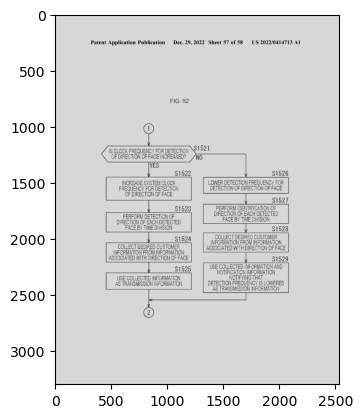

In [44]:
image_folder_path = "Patent Images/"

# generate the segments using the sam model and store it's result 
for image_file in tqdm_notebook(sorted(os.listdir(image_folder_path))):
    image_file_path = os.path.join(image_folder_path, image_file)
    if os.path.isfile(image_file_path) and image_file.lower().endswith(('.png','.jpg')):
        
        #extracting images from the folder using imread from cv2
        image = cv2.imread(image_file_path)
        
        #dont images which are not None
        if image is None:
            continue
        
        raw_image_box, raw_image_word = infer_on_raw_image(image)
        fully_processed_image_box, fully_processed_image_word = infer_on_fully_processed_image(image)
        
        save_this = {
            "image_file": image_file,
            "raw_image_box": raw_image_box,
            "raw_image_word": raw_image_word,
            "fully_processed_image_box": fully_processed_image_box,
            "fully_processed_image_word": fully_processed_image_word
        }
    
        os.makedirs("../outputs/inference", exist_ok=True)
        with open(f'../outputs/inference/{image_file.split(".")[0]}.pkl', 'wb') as f:
            # Use pickle.dump() to serialize and write the object to the file
            pickle.dump(save_this, f)

In[88]:

# Load the inference results from disk

In [1]:
import pickle
import os
from tqdm.notebook import tqdm_notebook

def load_inference_results_on_raw_images(inference_results_dir):
    image_files = []
    boxes = []
    words = []
    
    for pkl_file in tqdm_notebook(os.listdir(inference_results_dir)):
        full_path = os.path.join(inference_results_dir, pkl_file)
        with open(full_path, "rb") as f:
            pkl_obj = pickle.load(f)
        image_files.append((pkl_obj["image_file"], len(image_files)))
        boxes.append(pkl_obj["raw_image_box"])
        words.append(pkl_obj["raw_image_word"])
        
    # sort boxes and words based on image_files
    image_files.sort()
    boxes = [boxes[i] for (_,i) in image_files]
    words = [words[i] for (_,i) in image_files]

    return boxes, words

def load_inference_results_on_fully_processed_images(inference_results_dir):
    image_files = []
    boxes = []
    words = []
    
    for pkl_file in tqdm_notebook(os.listdir(inference_results_dir)):
        full_path = os.path.join(inference_results_dir, pkl_file)
        with open(full_path, "rb") as f:
            pkl_obj = pickle.load(f)
        image_files.append((pkl_obj["image_file"], len(image_files)))
        boxes.append(pkl_obj["fully_processed_image_box"])
        words.append(pkl_obj["fully_processed_image_word"])

    # sort boxes and words based on image_files
    image_files.sort()
    boxes = [boxes[i] for (_,i) in image_files]
    words = [words[i] for (_,i) in image_files]

    return boxes, words

In [2]:
raw_image_boxes, raw_image_words = load_inference_results_on_raw_images("../outputs/inference")

  0%|          | 0/549 [00:00<?, ?it/s]

In [3]:
fully_processed_image_boxes, fully_processed_image_words = load_inference_results_on_fully_processed_images("../outputs/inference")

  0%|          | 0/549 [00:00<?, ?it/s]

In [4]:
len(raw_image_boxes), len(raw_image_words), len(fully_processed_image_boxes), len(fully_processed_image_words)

(549, 549, 549, 549)

# Load groundtruth Excel file

In [25]:
import pandas as pd

df = pd.read_excel("Flowchart Data.xlsx")

# Using ChatGPT to make sense of the data obtained

# Evaluating ChatGPT Enhanced text

In[118]:

In [18]:
prompts1 = []
for x in fully_processed_image_words:
    prompts1.append(str(x))

In[120]:

In [19]:
prec = []
rec = []
f1_s = []

In[121]:

In [20]:
from bert_score import score

# Example sentences
for x,y in zip(df['TEXT IN IMAGES'],prompts1):
    reference = [x]
    candidate = [y]

# Calculate BERTScore
    P, R, F1 = score(candidate, reference, lang="en")

# Print results
    for ref, can, p, r, f1 in zip(reference, candidate, P, R, F1):
        prec.append(p)
        rec.append(r)
        f1_s.append(f1)

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You sho

In[123]:

In [21]:
print(sum(prec)/549)
print(sum(rec)/549)
print(sum(f1_s)/549)

tensor(0.7289)
tensor(0.8211)
tensor(0.7720)


In[124]:

In [9]:
prec_gpt = []
rec_gpt = []
f1_s_gpt = []

In[125]:

In [10]:
prompts2 = []
for x in fully_processed_image_words:
    prompts2.append("correct the text detected by pytesseract:"+str(x))

In[126]:

In [11]:
from openai import OpenAI

client = OpenAI()

In[127]:

In [12]:
c = 0
answer_gpt_pytesseract = []
for x in prompts2:
    c = c+1
    print(c)
    
    response = client.chat.completions.create(
        model="gpt-3.5-turbo-0125",  # or whichever model you want
        messages=[
            {"role": "system", "content": x}
        ]
    )
    answer_gpt_pytesseract.append(response.choices[0].message.content.replace('\n', '').replace(' .', '.').strip())

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


In[128]:

In [13]:
from bert_score import score

# Example sentences
for x,y in zip(df['TEXT IN IMAGES'],answer_gpt_pytesseract):
    reference = [x]
    candidate = [y]

# Calculate BERTScore
    P, R, F1 = score(candidate, reference, lang="en")

# Print results
    for ref, can, p, r, f1 in zip(reference, candidate, P, R, F1):
        prec_gpt.append(p)
        rec_gpt.append(r)
        f1_s_gpt.append(f1)

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You sho

In[130]:

In [14]:
print(sum(prec_gpt)/549)
print(sum(rec_gpt)/549)
print(sum(f1_s_gpt)/549)

tensor(0.8319)
tensor(0.8344)
tensor(0.8328)


# Evaluating description of Flowcharts:

In[123]:

In [14]:
prompts = []

for x,y in zip(raw_image_words,raw_image_boxes):
    prompts.append("Give a detailed and descriptive interpretation of the flowchart in the form of steps using following details pytesseract text recognition data:"+str(x)+"bounding box info obtained from sam(segment anything model):"+str(y))

In[124]:

In [15]:
from openai import OpenAI

client = OpenAI()

In[199]:

In [16]:
c = 0
answer1 = []
for x in prompts:
    c = c+1
    print(c)
    
    response = client.chat.completions.create(
        model="gpt-3.5-turbo-0125",  # or whichever model you want
        messages=[
            {"role": "system", "content": x}
        ],
        max_tokens=500
    )
    answer1.append(response.choices[0].message.content.replace('\n', '').replace(' .', '.').strip())

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


In[201]:

In [17]:
zero_shot_prec = []
zero_shot_rec = []
zero_shot_f1_s = []

In[202]:

In [18]:
from bert_score import score

# Example sentences
for x,y in zip(df['DESCRIPTION'],answer1):
    reference = [x]
    candidate = [y]

# Calculate BERTScore
    P, R, F1 = score(candidate, reference, lang="en")

# Print results
    for ref, can, p, r, f1 in zip(reference, candidate, P, R, F1):
        zero_shot_prec.append(p)
        zero_shot_rec.append(r)
        zero_shot_f1_s.append(f1)

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You sho

In[258]:

In [19]:
print(sum(zero_shot_prec)/549)
print(sum(zero_shot_rec)/549)
print(sum(zero_shot_f1_s)/549)

tensor(0.8162)
tensor(0.8504)
tensor(0.8327)


In[171]:

In [15]:
input1 = "Give a detailed and descriptive interpretation of the flowchart in the form of steps using following details pytesseract text recognition data: bounding box info obtained from sam(segment anything model):[[1191, 835, 51, 18], [850, 668, 60, 23], [583, 262, 52, 17], [514, 262, 62, 18], [1345, 835, 43, 18], [1230, 655, 49, 17], [475, 235, 54, 18], [1284, 656, 66, 16], [151, 237, 14, 16], [1286, 540, 14, 65], [84, 10, 264, 175], [84, 10, 264, 121], [85, 11, 262, 510], [84, 10, 263, 260], [0, 0, 1451, 949], [442, 192, 265, 132], [535, 238, 89, 15], [88, 189, 255, 139], [441, 407, 264, 131], [88, 407, 617, 131], [798, 407, 264, 132], [84, 407, 264, 131], [1155, 407, 275, 300], [1155, 407, 275, 132], [797, 611, 617, 132], [797, 612, 264, 132], [1165, 607, 256, 141], [1150, 805, 286, 131]]the text in each of those bounding boxes['', '', '', '', '', '', '', '', '', '', 'Customer places\\n\\nan order\\n', 'Yes\\n', '', 'Customer places\\nan order\\n\\nIs item still in Email customer and\\nstock? cancel order\\n\\nEmail customer with\\nHand off to carrier shipping confirmation\\nand tracking info\\n\\nDoes carrier\\n\\nNotify customer\\n\\ndeliver item?\\n\\nEmail customer with\\n\\nconfirmation of delivery\\nand return instructions\\n', 'Email customer and_\\ncancel order\\n', '', '', 'Print label\\n', 'Pack item Print label\\n', 'Hand off to carrier\\n', 'Pack item\\n', 'Does carrier\\ndeliver item?\\n', '<—No—\\n', '', '', 'Email customer with\\nconfirmation of delivery\\n\\nCoes return ——\\n']"

In[172]:

In [16]:
knowledge1 = '''1.Customer places an order: When a customer initiates an order, this is the starting point of the process. 
2.Is the item still in stock?: A decision box where we check if the item is still in stock if it is pack the item else email the customer and cancel the order
3. Email customer and cancel order: If the item is no longer in stock, this step involves notifying the customer and canceling the order. 
4.Pack item: Once we pack the item , we print the label on the item.
5.Print label: Once we label is printed , we move to the next step handoff to carrier
6.Handoff to carrier: The item is handed over to the carrier for delivery 
7.Email customer with shipping confirmation and tracking info: Assuming the item is in stock, this step involves informing the customer about the shipment with tracking details. 7.Does the carrier deliver the item?: A branching point where the process checks if the carrier delivers the item, if it does, Email customer with confirmation of delivery and return instructions , else notify the customer and cancel the order.'''


In[173]:

In [17]:
input2 = "Give a detailed and descriptive interpretation of the flowchart in the form of steps using following details pytesseract text recognition data: bounding box info obtained from sam(segment anything model):[[42, 164, 17, 6], [27, 89, 32, 8], [95, 158, 14, 6], [166, 169, 17, 6], [129, 83, 4, 5], [59, 205, 10, 6], [160, 83, 19, 7], [129, 169, 33, 8], [26, 176, 28, 6], [46, 218, 10, 10], [143, 84, 3, 7], [58, 120, 14, 6], [97, 72, 11, 6], [104, 73, 4, 5], [46, 131, 10, 11], [56, 164, 3, 6], [12, 14, 3, 6], [66, 207, 3, 4], [111, 168, 11, 10], [58, 176, 17, 6], [129, 83, 17, 8], [111, 82, 10, 10], [46, 203, 10, 26], [39, 77, 23, 8], [12, 14, 22, 8], [46, 45, 10, 11], [162, 84, 4, 5], [68, 121, 4, 5], [97, 72, 5, 5], [42, 164, 4, 6], [59, 205, 5, 6], [96, 81, 25, 11], [96, 86, 14, 1], [46, 31, 10, 25], [51, 31, 0, 14], [46, 117, 10, 26], [51, 117, 0, 14], [51, 203, 0, 14], [51, 31, 0, 14], [51, 117, 0, 14], [95, 158, 5, 6], [57, 238, 19, 8], [51, 203, 0, 14], [63, 121, 9, 5], [8, 5, 86, 25], [8, 5, 86, 40], [8, 5, 86, 110], [122, 74, 64, 25], [6, 57, 89, 59], [6, 45, 105, 86], [6, 57, 180, 59], [0, 0, 191, 261], [124, 161, 64, 24], [6, 144, 89, 58], [6, 144, 89, 84], [19, 173, 78, 82], [19, 230, 64, 25], [19, 218, 64, 37]]the text in each of those bounding boxes['', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '[Lamp doesnt work\\n', '', '', '', 'Lamp\\nplunged in?\\n', '', 'Replace bulb\\n', '', 'burned out?\\n\\nRepair lamp\\n', '', '']"

In[174]:

In [18]:
knowledge2 = '''1.Lamp Doesn't Work: In this state , the lamp is not working and move on to check if lamp is plugged in
2. Lamp Plugged in?: A decision point. It checks whether the lamp is plugged in. If it is not then plugin lamp , else check if bulb burned out.
3.Bulb burned out :Check if bulb is burned out , if yes replace bulb else repair lamp'''


In[178]:

In [19]:
prompts = []

for x,y in zip(raw_image_words,raw_image_boxes):
    prompts.append("Give a detailed and descriptive interpretation of the flowchart in the form of steps using following details pytesseract text recognition data:"+str(x)+"bounding box info obtained from sam(segment anything model):"+str(y))

In[176]:

In [20]:
from openai import OpenAI

client = OpenAI()

In[204]:

In [21]:
c = 0
answer2 = []
for x in prompts:
    c = c+1
    print(c)
    
    response = client.chat.completions.create(
        model="gpt-3.5-turbo-0125",  # or whichever model you want
        messages=[
            {"role": "system", "content": "You describe flowcharts."},
            {"role": "user", "content":input1},
            {"role": "assistant", "content":knowledge1},
            {"role": "user", "content":input2},
            {"role": "assistant", "content":knowledge2},
            {"role": "user", "content":x}],
        max_tokens=1000
    )
    answer2.append(response.choices[0].message.content.replace('\n', '').replace(' .', '.').strip())

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


In[57]:

In [22]:
len(answer2)

549

In[205]:

In [23]:
instruction_based_prec = []
instruction_based_rec = []
instruction_based_f1_s = []

In[206]:

In [26]:
from bert_score import score

# Example sentences
for x,y in zip(df['DESCRIPTION'],answer2):
    reference = [x]
    candidate = [y]

# Calculate BERTScore
    P, R, F1 = score(candidate, reference, lang="en")

# Print results
    for ref, can, p, r, f1 in zip(reference, candidate, P, R, F1):
        instruction_based_prec.append(p)
        instruction_based_rec.append(r)
        instruction_based_f1_s.append(f1)

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You sho

In[257]:

In [27]:
print(sum(instruction_based_prec)/549)
print(sum(instruction_based_rec)/549)
print(sum(instruction_based_f1_s)/549)

tensor(0.8569)
tensor(0.8578)
tensor(0.8572)


In[208]:

The below requires computation of OCR of entire raw images stored in `images_text`.
Please run the corresponding code high above.

In [ ]:
prompts = []

for x in images_text:
    prompts.append("Give a detailed and descriptive interpretation of the flowchart in the form of steps using following details pytesseract text recognition data:"+str(x))

In[209]:

In [ ]:
from openai import OpenAI

client = OpenAI()

In[252]:

In [ ]:
c = 0
answer3 = []
for x in prompts:
    c = c+1
    print(c)
    
    response = client.chat.completions.create(
        model="gpt-3.5-turbo-0125",  # or whichever model you want
        messages=[
            {"role": "system", "content": x}
        ],
        max_tokens=500
    )
    answer3.append(response.choices[0].message.content.replace('\n', '').replace(' .', '.').strip())

In[254]:

In [ ]:
zero_shot_prec_ablation = []
zero_shot_rec_ablation = []
zero_shot_f1_s_ablation = []

In[255]:

In [ ]:
from bert_score import score

# Example sentences
for x,y in zip(df['DESCRIPTION'],answer3):
    reference = [x]
    candidate = [y]

# Calculate BERTScore
    P, R, F1 = score(candidate, reference, lang="en")

# Print results
    for ref, can, p, r, f1 in zip(reference, candidate, P, R, F1):
        zero_shot_prec_ablation.append(p)
        zero_shot_rec_ablation.append(r)
        zero_shot_f1_s_ablation.append(f1)

In[259]:

In [ ]:
print(sum(zero_shot_prec_ablation)/549)
print(sum(zero_shot_rec_ablation)/549)
print(sum(zero_shot_f1_s_ablation)/549)

In[230]:

In [ ]:
input1_ablation = "Give a detailed and descriptive interpretation of the flowchart in the form of steps using following details pytesseract text recognition data: [Lamp doesn't work]\n\nLamp\n\nplugged in? >) Plug in lamp |\n\nBulb\nburned out?\n\n—J)\n\nReplace bulb\n\n[ Repair lamp |\n\n"

In[231]:

knowledge1_ablation = 
1.Customer places an order: When a customer initiates an order, this is the starting point of the process. <br>
2.Is the item still in stock?: A decision box where we check if the item is still in stock if it is pack the item else email the customer and cancel the order<br>
3. Email customer and cancel order: If the item is no longer in stock, this step involves notifying the customer and canceling the order. <br>
4.Pack item: Once we pack the item , we print the label on the item.<br>
5.Print label: Once we label is printed , we move to the next step handoff to carrier<br>
6.Handoff to carrier: The item is handed over to the carrier for delivery <br>
7.Email customer with shipping confirmation and tracking info: Assuming the item is in stock, this step involves informing the customer about the shipment with tracking details. 7.Does the carrier deliver the item?: A branching point where the process checks if the carrier delivers the item, if it does, Email customer with confirmation of delivery and return instructions , else notify the customer and cancel the order.<br>


In[232]:

In [ ]:
input2_ablation = "Give a detailed and descriptive interpretation of the flowchart in the form of steps using following details pytesseract text recognition data: Customer places\n\nEmail customer and\ncan\n\ncel order\n\nEmail customer with\nHand off to carrier shipping confirmation\nand tracking info\n\n’ Does carrier\nNotify customer deliver item?\n\nEmail customer with\n\nai\nconfirmation of delivery\nand return instructions\n"

In[233]:

knowledge2_ablation = 
1.Lamp Doesn't Work: In this state , the lamp is not working and move on to check if lamp is plugged in<br>
2. Lamp Plugged in?: A decision point. It checks whether the lamp is plugged in. If it is not then plugin lamp , else check if bulb burned out.<br>
3.Bulb burned out :Check if bulb is burned out , if yes replace bulb else repair lamp<br>


In[220]:

In [ ]:
prompts = []

for x in images_text:
    prompts.append("Give a detailed and descriptive interpretation of the flowchart in the form of steps using following details pytesseract text recognition data:"+str(x))

In[221]:

In [ ]:
from openai import OpenAI

client = OpenAI()

In[234]:

In [ ]:
c = 0
answer4 = []
for x in prompts:
    c = c+1
    print(c)
    
    response = client.chat.completions.create(
        model="gpt-3.5-turbo-0125",  # or whichever model you want,
        messages=[
            {"role": "system", "content": "You describe flowcharts."},
            {"role": "user", "content":input1_ablation},
            {"role": "assistant", "content":knowledge1_ablation},
            {"role": "user", "content":input2_ablation},
            {"role": "assistant", "content":knowledge2_ablation},
            {"role": "user", "content":x}
        ]
        max_tokens=1000
    )
    answer4.append(response.choices[0].message.content.replace('\n', '').replace(' .', '.').strip())

In[235]:

In [ ]:
instruction_based_prec_ablation = []
instruction_based_rec_ablation = []
instruction_based_f1_s_ablation = []

In[236]:

In [ ]:
from bert_score import score

# Example sentences
for x,y in zip(df['DESCRIPTION'],answer4):
    reference = [x]
    candidate = [y]

# Calculate BERTScore
    P, R, F1 = score(candidate, reference, lang="en")

# Print results
    for ref, can, p, r, f1 in zip(reference, candidate, P, R, F1):
        instruction_based_prec_ablation.append(p)
        instruction_based_rec_ablation.append(r)
        instruction_based_f1_s_ablation.append(f1)

In[261]:

In [ ]:
print(sum(instruction_based_prec_ablation)/549)
print(sum(instruction_based_rec_ablation)/549)
print(sum(instruction_based_f1_s_ablation)/549)

In[135]:

In [33]:
"".split()

[]

In [ ]:
df['Description']

In [ ]:
from gensim.models import KeyedVectors
import string

# Load pre-trained Word2Vec model (example using Google's Word2Vec model)
model_path = '~/gensim-data/word2vec-google-news-300/word2vec-google-news-300.gz'
word2vec_model = KeyedVectors.load_word2vec_format(model_path, binary=True)

# Tokenize and preprocess sentences
similarity1 = []
# Remove punctuation from tokens
for x,y in zip(df['DESCRIPTION'],df['zero_shot_prompting']):
    translator = str.maketrans("", "", string.punctuation)
    tokens1 = x.lower().translate(translator).split()
    tokens2 = y.lower().translate(translator).split()

    # Check if tokens are present in the model's vocabulary
    tokens1 = [token for token in tokens1 if token in word2vec_model.key_to_index]
    tokens2 = [token for token in tokens2 if token in word2vec_model.key_to_index]

    # Calculate similarity between two sentences
    similarity_score = word2vec_model.n_similarity(tokens1, tokens2)
    print(f"Similarity Score: {similarity_score}")
    similarity1.append(similarity_score)

In[136]:

In [ ]:
sum(similarity1)/549

In[ ]:

In [ ]:
from gensim.models import KeyedVectors
import string

# Load pre-trained Word2Vec model (example using Google's Word2Vec model)
model_path = '~/gensim-data/word2vec-google-news-300/word2vec-google-news-300.gz'
word2vec_model = KeyedVectors.load_word2vec_format(model_path, binary=True)

# Tokenize and preprocess sentences
sentence1 = "This is the first sentence."
sentence2 = "My name is Arbaz"
similarity2 = []
# Remove punctuation from tokens
for x,y in zip(df['DESCRIPTION'],df['instruction_based_prompting:']):
    translator = str.maketrans("", "", string.punctuation)
    tokens1 = x.lower().translate(translator).split()
    tokens2 = y.lower().translate(translator).split()

    # Check if tokens are present in the model's vocabulary
    tokens1 = [token for token in tokens1 if token in word2vec_model.key_to_index]
    tokens2 = [token for token in tokens2 if token in word2vec_model.key_to_index]

    # Calculate similarity between two sentences
    similarity_score = word2vec_model.n_similarity(tokens1, tokens2)
    print(f"Similarity Score: {similarity_score}")
    similarity2.append(similarity_score)

In[138]:

In [ ]:
sum(similarity2)/549

In[139]:

In [ ]:
from gensim.models import KeyedVectors
import string

# Load pre-trained Word2Vec model (example using Google's Word2Vec model)
model_path = '~/gensim-data/word2vec-google-news-300/word2vec-google-news-300.gz'
word2vec_model = KeyedVectors.load_word2vec_format(model_path, binary=True)

# Tokenize and preprocess sentences
sentence1 = "This is the first sentence."
sentence2 = "My name is Arbaz"
similarity3 = []
# Remove punctuation from tokens
for x,y in zip(df['DESCRIPTION'],df['zero_shot_prompting_ablation']):
    translator = str.maketrans("", "", string.punctuation)
    tokens1 = x.lower().translate(translator).split()
    tokens2 = y.lower().translate(translator).split()

    # Check if tokens are present in the model's vocabulary
    tokens1 = [token for token in tokens1 if token in word2vec_model.key_to_index]
    tokens2 = [token for token in tokens2 if token in word2vec_model.key_to_index]

    # Calculate similarity between two sentences
    similarity_score = word2vec_model.n_similarity(tokens1, tokens2)
    print(f"Similarity Score: {similarity_score}")
    similarity3.append(similarity_score)

In[140]:

In [ ]:
sum(similarity3)/549

In[141]:

In [ ]:
from gensim.models import KeyedVectors
import string

# Load pre-trained Word2Vec model (example using Google's Word2Vec model)
model_path = '~/gensim-data/word2vec-google-news-300/word2vec-google-news-300.gz'
word2vec_model = KeyedVectors.load_word2vec_format(model_path, binary=True)

# Tokenize and preprocess sentences
sentence1 = "This is the first sentence."
sentence2 = "My name is Arbaz"
similarity4 = []
# Remove punctuation from tokens
for x,y in zip(df['DESCRIPTION'],df['instruction_based_prompting_ablation']):
    translator = str.maketrans("", "", string.punctuation)
    tokens1 = x.lower().translate(translator).split()
    tokens2 = y.lower().translate(translator).split()

    # Check if tokens are present in the model's vocabulary
    tokens1 = [token for token in tokens1 if token in word2vec_model.key_to_index]
    tokens2 = [token for token in tokens2 if token in word2vec_model.key_to_index]

    # Calculate similarity between two sentences
    similarity_score = word2vec_model.n_similarity(tokens1, tokens2)
    print(f"Similarity Score: {similarity_score}")
    similarity4.append(similarity_score)

In[142]:

In [ ]:
sum(similarity4)/549

In[148]:

In [ ]:
from sentence_transformers import SentenceTransformer, util

# Load a pre-trained SBERT model
sbert_model = SentenceTransformer('paraphrase-MiniLM-L6-v2')

# Define your sentences
sentence1 = "This is the first sentence."
sentence2 = "This is the first sentence."

# Encode the sentences using SBERT
s1 = []
for x,y in zip(df['DESCRIPTION'],df['zero_shot_prompting']):
    embedding1 = sbert_model.encode([x], convert_to_tensor=True)
    embedding2 = sbert_model.encode([y], convert_to_tensor=True)

    # Calculate cosine similarity between the embeddings
    cosine_similarity = util.pytorch_cos_sim(embedding1, embedding2)[0][0].item()
    print(f"Cosine Similarity: {cosine_similarity}")
    s1.append(cosine_similarity)

In[150]:

In [ ]:
sum(s1)/549

In[151]:

In [ ]:
from sentence_transformers import SentenceTransformer, util

# Load a pre-trained SBERT model
sbert_model = SentenceTransformer('paraphrase-MiniLM-L6-v2')

# Define your sentences
sentence1 = "This is the first sentence."
sentence2 = "This is the first sentence."

# Encode the sentences using SBERT
s2 = []
for x,y in zip(df['DESCRIPTION'],df['instruction_based_prompting:']):
    embedding1 = sbert_model.encode([x], convert_to_tensor=True)
    embedding2 = sbert_model.encode([y], convert_to_tensor=True)

    # Calculate cosine similarity between the embeddings
    cosine_similarity = util.pytorch_cos_sim(embedding1, embedding2)[0][0].item()
    print(f"Cosine Similarity: {cosine_similarity}")
    s2.append(cosine_similarity)

In[152]:

In [ ]:
sum(s2)/549

In[153]:

In [ ]:
from sentence_transformers import SentenceTransformer, util

# Load a pre-trained SBERT model
sbert_model = SentenceTransformer('paraphrase-MiniLM-L6-v2')

# Define your sentences
sentence1 = "This is the first sentence."
sentence2 = "This is the first sentence."

# Encode the sentences using SBERT
s3 = []
for x,y in zip(df['DESCRIPTION'],df['zero_shot_prompting_ablation']):
    embedding1 = sbert_model.encode([x], convert_to_tensor=True)
    embedding2 = sbert_model.encode([y], convert_to_tensor=True)

    # Calculate cosine similarity between the embeddings
    cosine_similarity = util.pytorch_cos_sim(embedding1, embedding2)[0][0].item()
    print(f"Cosine Similarity: {cosine_similarity}")
    s3.append(cosine_similarity)

In[154]:

In [ ]:
sum(s3)/549

In[155]:

In [ ]:
from sentence_transformers import SentenceTransformer, util

# Load a pre-trained SBERT model
sbert_model = SentenceTransformer('paraphrase-MiniLM-L6-v2')

# Define your sentences
sentence1 = "This is the first sentence."
sentence2 = "This is the first sentence."

# Encode the sentences using SBERT
s4 = []
for x,y in zip(df['DESCRIPTION'],df['instruction_based_prompting_ablation']):
    embedding1 = sbert_model.encode([x], convert_to_tensor=True)
    embedding2 = sbert_model.encode([y], convert_to_tensor=True)

    # Calculate cosine similarity between the embeddings
    cosine_similarity = util.pytorch_cos_sim(embedding1, embedding2)[0][0].item()
    print(f"Cosine Similarity: {cosine_similarity}")
    s4.append(cosine_similarity)

In[156]:

In [ ]:
sum(s4)/549

In[19]:

In [ ]:
from sentence_transformers import SentenceTransformer, util

model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
c = 0
instruction_based = []
for x,y in zip(df['DESCRIPTION'] ,df['instruction_based_prompting:']):
    sentences = [x,y]

#Compute embedding for both lists
    embedding_1= model.encode(sentences[0], convert_to_tensor=True)
    embedding_2 = model.encode(sentences[1], convert_to_tensor=True)

    instruction_based.append(util.pytorch_cos_sim(embedding_1, embedding_2))
    c = c+1
    print(c)
## tensor([[0.6003]])

In[20]:

In [ ]:
sum(instruction_based)/549

In[23]:

In [ ]:
from sentence_transformers import SentenceTransformer, util

zero_based_a = []
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
c = 0 
for x,y in zip(df['DESCRIPTION'] ,df['zero_shot_prompting_ablation'] ):
    sentences = [x,y]

#Compute embedding for both lists
    embedding_1= model.encode(sentences[0], convert_to_tensor=True)
    embedding_2 = model.encode(sentences[1], convert_to_tensor=True)

    zero_based_a.append(util.pytorch_cos_sim(embedding_1, embedding_2))
    c = c+1
    print(c)
## tensor([[0.6003]])

In[24]:

In [ ]:
sum(zero_based_a)/549

In[25]:

In [ ]:
from sentence_transformers import SentenceTransformer, util

instruction_based_a = []
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
c = 0
for x,y in zip(df['DESCRIPTION'] ,df['instruction_based_prompting_ablation']):
    sentences = [x,y]
#Compute embedding for both lists
    embedding_1= model.encode(sentences[0], convert_to_tensor=True)
    embedding_2 = model.encode(sentences[1], convert_to_tensor=True)

    instruction_based_a.append(util.pytorch_cos_sim(embedding_1, embedding_2))
    c = c+1
    print(c)
    
## tensor([[0.6003]])

In[26]:

In [ ]:
sum(instruction_based_a)/549

In[64]: